In [135]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [136]:
import pandas as pd
import seaborn as sns
#********************************************
import numpy as np 
import matplotlib.pyplot as plt
#********************************************
import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [137]:
# Let us begin with Train data
import kagglehub
from pathlib import Path

data_folder = Path(
    kagglehub.dataset_download(
        "keplersmachines/kepler-labelled-time-series-data"
    )
)

train_df = pd.read_csv(data_folder / "exoTrain.csv")
train_df.head(10)

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
5,2,211.10,163.57,179.16,187.82,188.46,168.13,203.46,178.65,166.49,...,-98.45,30.34,30.34,29.62,28.80,19.27,-43.90,-41.63,-52.90,-16.16
6,2,9.34,49.96,33.30,9.63,37.64,20.85,4.54,22.42,10.11,...,-58.56,9.93,9.93,23.50,5.28,-0.44,10.90,-11.77,-9.25,-36.69
7,2,238.77,262.16,277.80,190.16,180.98,123.27,103.95,50.70,59.91,...,-72.48,31.77,31.77,53.48,27.88,95.30,48.86,-10.62,-112.02,-229.92
8,2,-103.54,-118.97,-108.93,-72.25,-61.46,-50.16,-20.61,-12.44,1.48,...,43.92,7.24,7.24,-7.45,-18.82,4.53,21.95,26.94,34.08,44.65
9,2,-265.91,-318.59,-335.66,-450.47,-453.09,-561.47,-606.03,-712.72,-685.97,...,3671.03,2249.28,2249.28,2437.78,2584.22,3162.53,3398.28,3648.34,3671.97,3781.91


In [138]:
# Check the shape of train data
train_df.shape

(5087, 3198)

In [139]:
# Display the rows with null values
train_df[train_df.isnull().any(axis = 1)] 

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197


<Axes: >

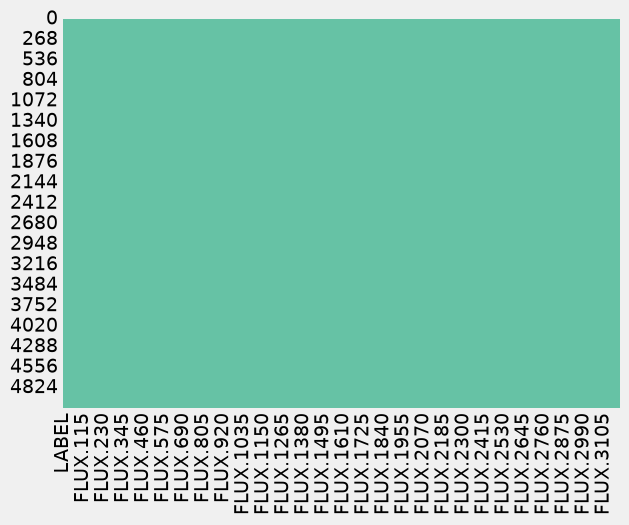

In [140]:
sns.heatmap(train_df.isnull(), cmap = 'Set2', cbar = False)

In [141]:
# Check how many labels are there
train_df['LABEL'].unique()

array([2, 1])

In [142]:
# Extract the index for the stars labelled as 2
idx_lab2 = list(train_df[train_df['LABEL'] == 2].index)
print(f"Index list for label 2 star in the data:-\n{idx_lab2}\n")

Index list for label 2 star in the data:-
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]



[Text(0, 0, '5050'), Text(0, 0, '37')]

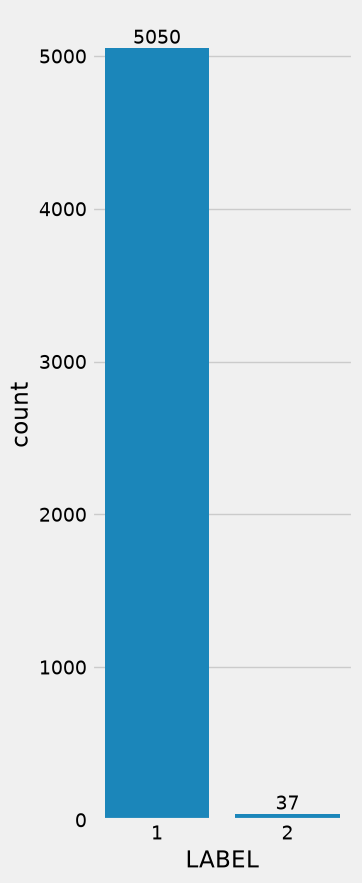

In [143]:
# Visualise these values using countplot
plt.figure(figsize = (3, 10))                                                   
ax = sns.countplot(x='LABEL',data=train_df)                    
ax.bar_label(ax.containers[0])

In [144]:
train_df = train_df.replace({'LABEL' : {1:0, 2:1}})
print("Replacing labels...")

# Check the labels now
print("Done!\n")
uniq_val = train_df.LABEL.unique()
print(f"There are {len(uniq_val)} classes in the data:-")
if len(uniq_val) >= 1:
     print(f"{uniq_val[0]} - Stars with Exoplanets")
if len(uniq_val) >= 2:      
      print(f"{uniq_val[1]} - Stars without Exoplantes")

Replacing labels...
Done!

There are 2 classes in the data:-
1 - Stars with Exoplanets
0 - Stars without Exoplantes


In [145]:
# Drop label column to plot only the flux values
plot_df = train_df.drop(['LABEL'], axis = 1)

# X - axis data: Replace FLUX. from each column names
col_names = list(plot_df.columns)
time = [int(flux_prefix.replace("FLUX.", "")) for flux_prefix in col_names]

# Function to plot flux variation of star
def flux_plot(df, candidate, exo = True):
    color = 'b' if exo == True else 'm'
    plt.figure(figsize=(15, 5))
    plt.plot(time, df.iloc[candidate-1], linewidth = .5, color = color)
    title1, clr1 = f"Flux Variation of star {candidate} with Exoplanents", 'olive'
    title2, clr2 = f"Flux Variation of star {candidate} without Exoplanets", 'tab:red'
    plt.title(title1, color = clr1) if exo == True else plt.title(title2, color = clr2)
    plt.xlabel("Time")
    plt.ylabel("Flux Variation")

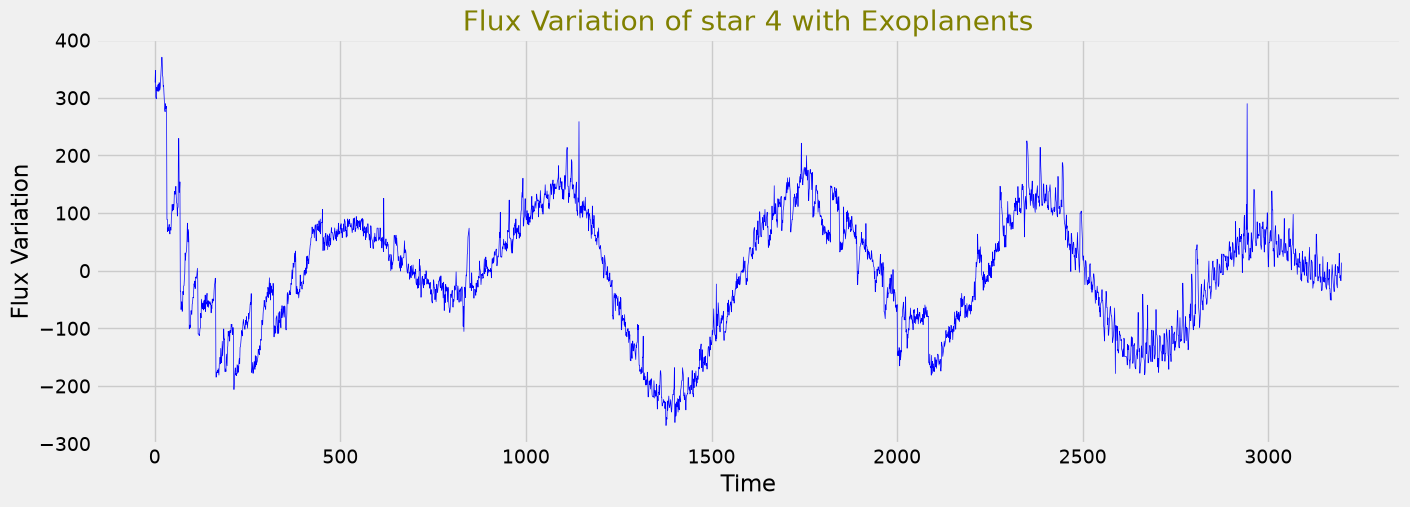

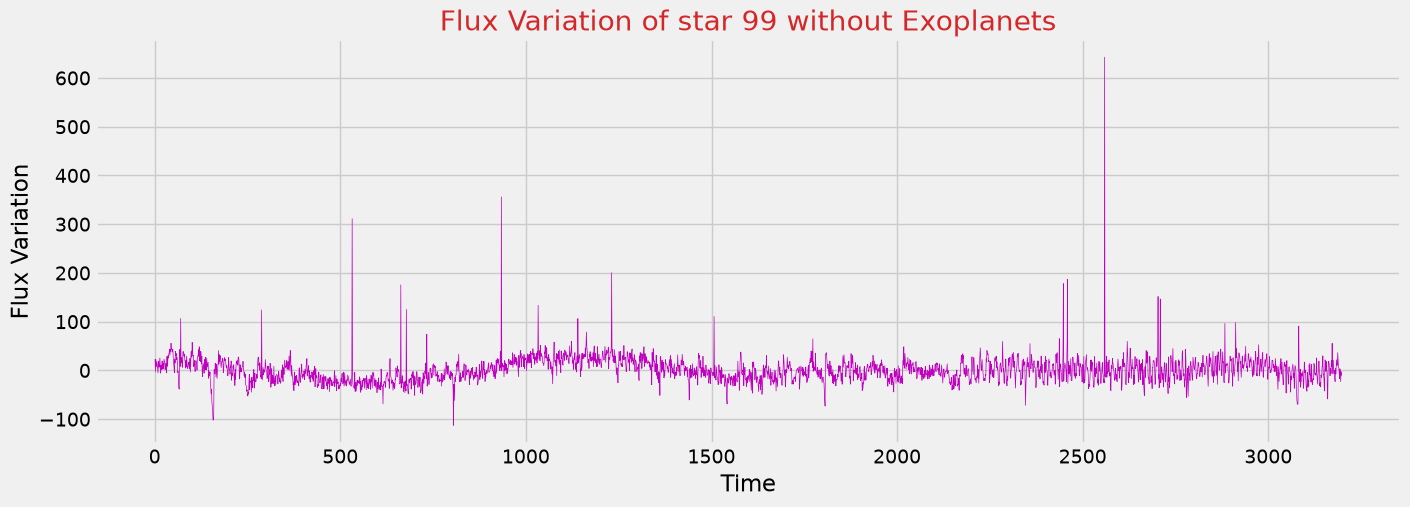

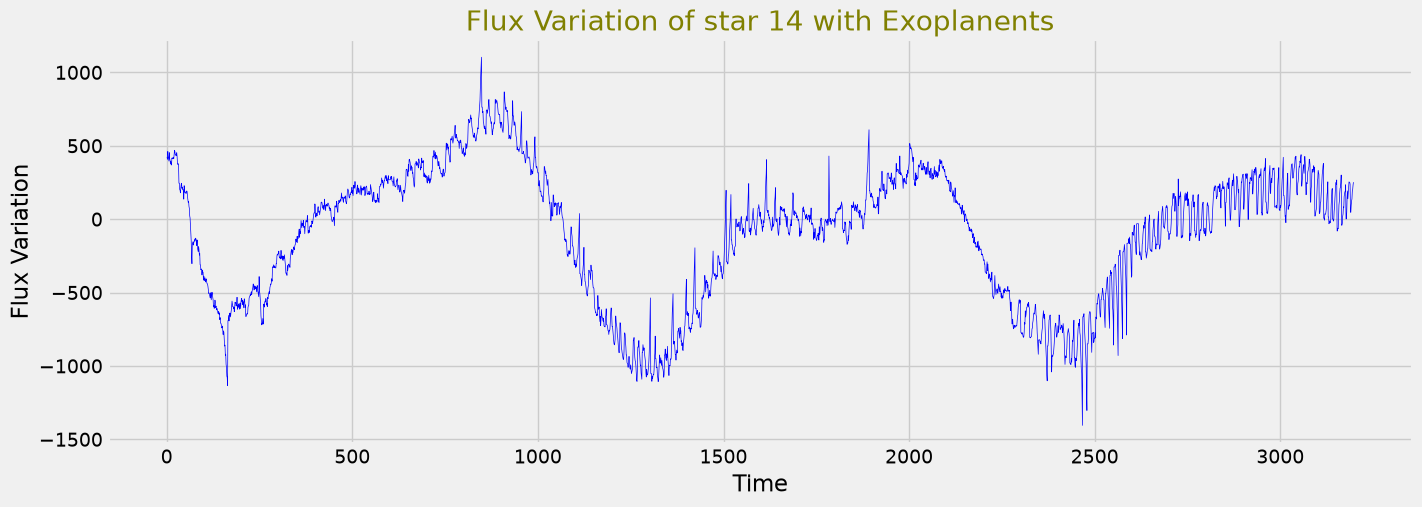

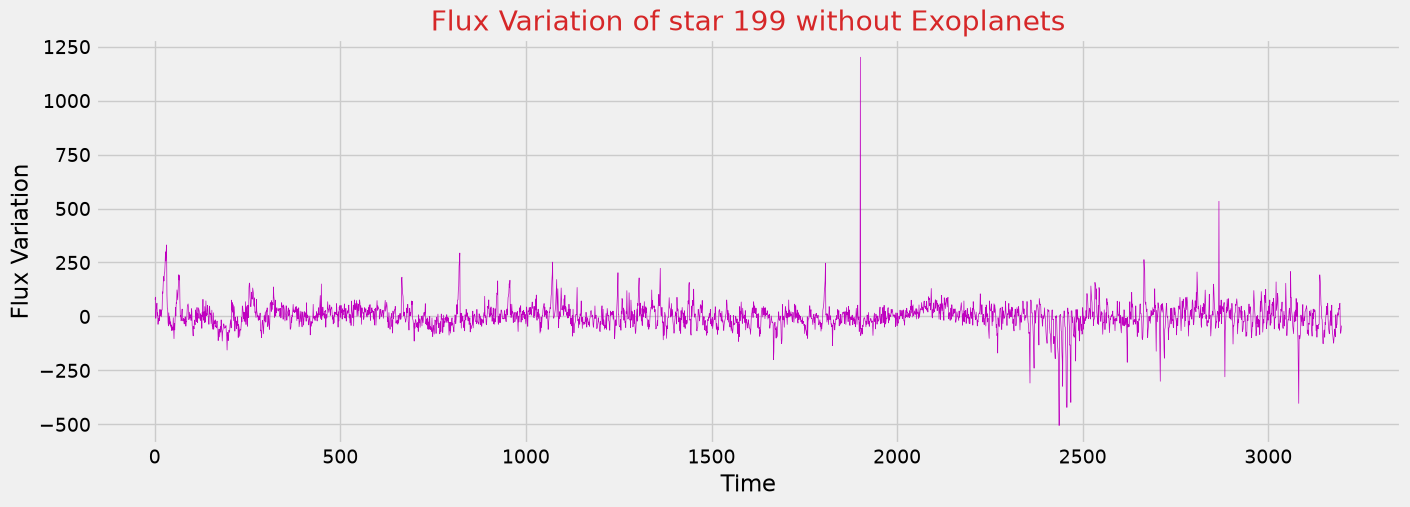

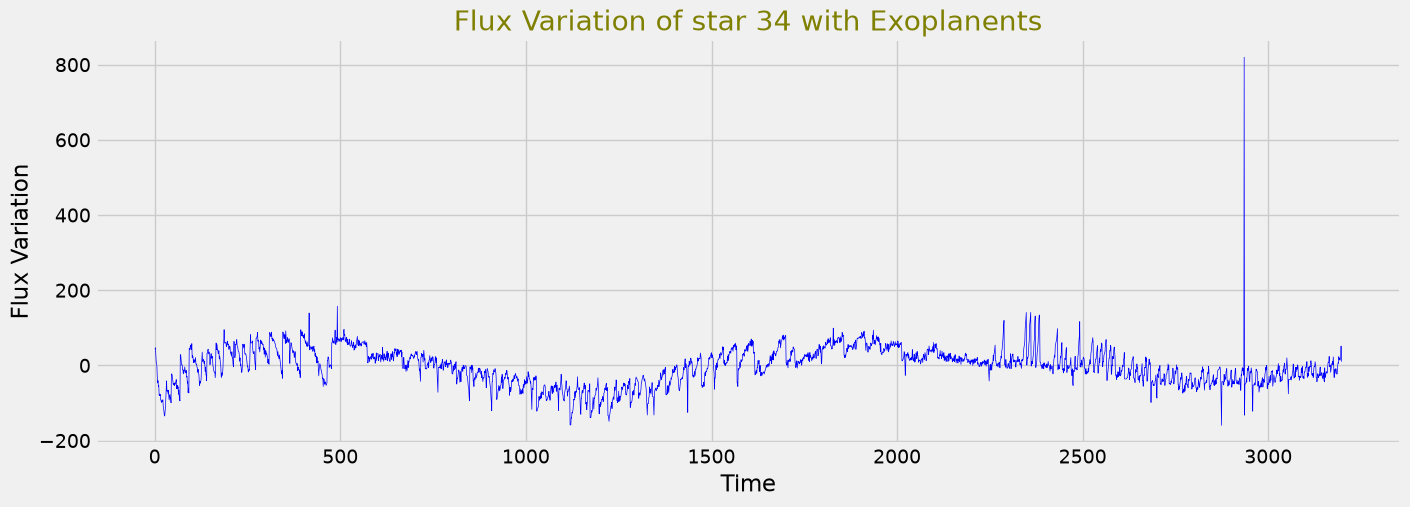

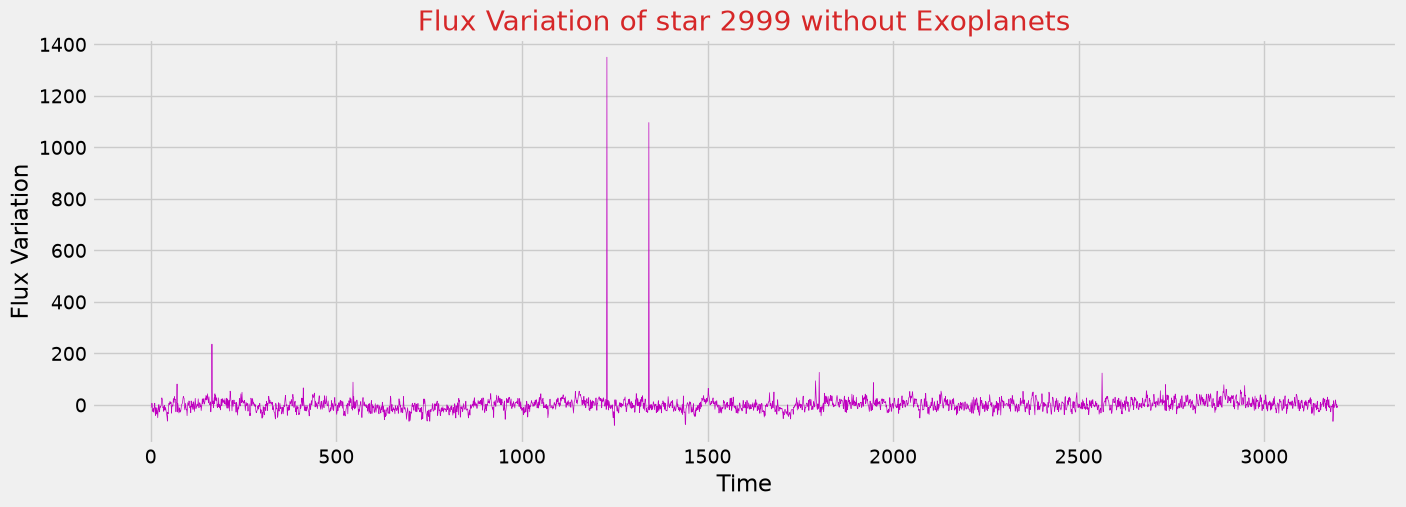

In [152]:
# Example of light curves
exo, n_exo = [4, 14, 34], [99, 199, 2999]

for candidate in range(len(exo)):
    flux_plot(plot_df, exo[candidate], exo = True)
    flux_plot(plot_df, n_exo[candidate], exo = False)

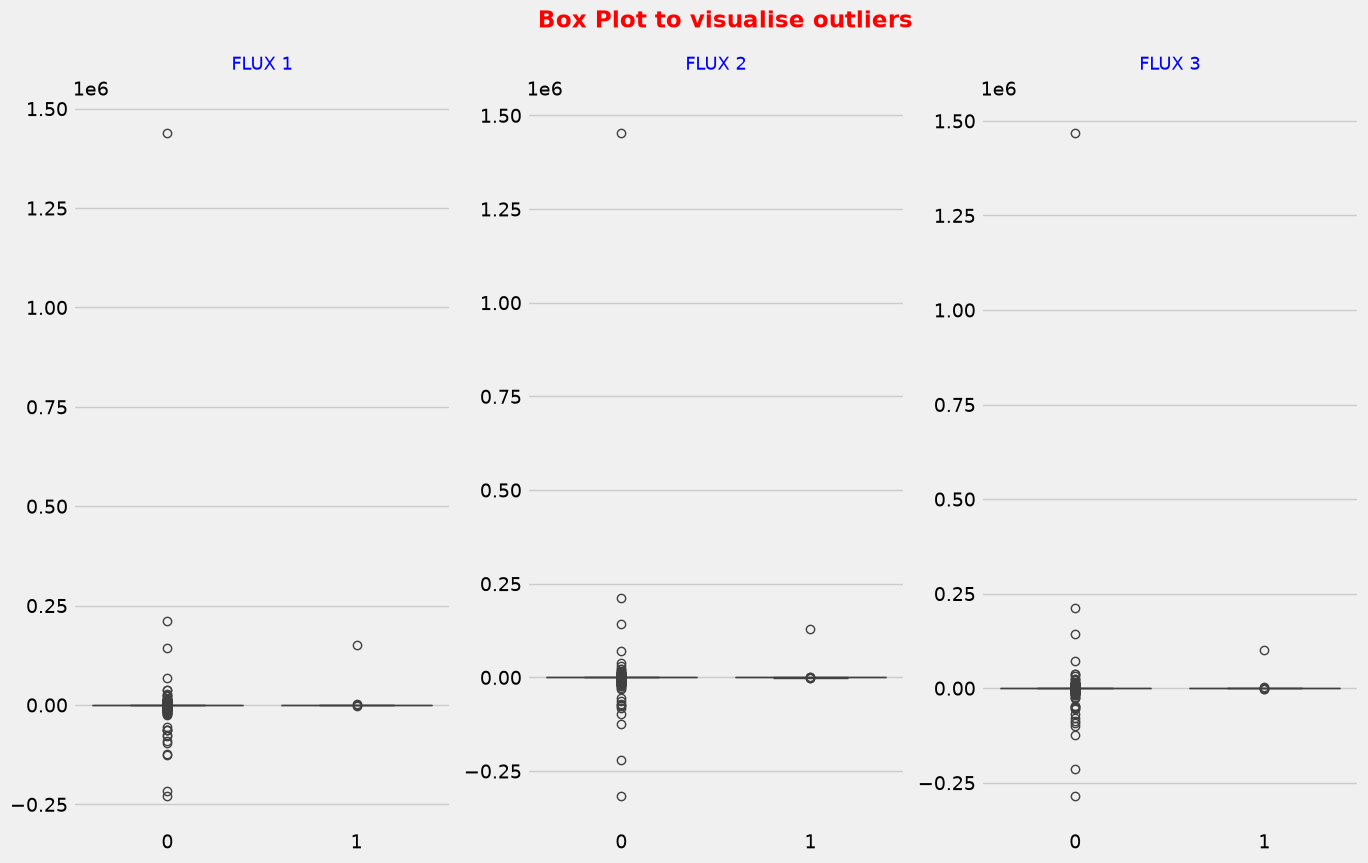

In [147]:
# Boxplot to visualise outliers
plt.figure(figsize = (20, 9))
plt.suptitle("Box Plot to visualise outliers", ha = 'right', color = 'red', weight = 'bold')
for i in range(1, 4):
    plt.subplot(1, 4, i)
    sns.boxplot(data=train_df, x='LABEL', y = 'FLUX.' + str(i))
    plt.xlabel("")
    plt.ylabel("")
    plt.title("FLUX " + str(i) + "\n", color = 'b', fontsize = 13)

In [148]:
# Extract dependent and independent features
x = train_df.drop(['LABEL'], axis = 1)
y = train_df.LABEL

print(f"Take a look over ~\n\nX train array:-\n{x.values}\n\nY train array:-\n{y.values}")

Take a look over ~

X train array:-
[[ 93.85  83.81  20.1  ...  61.42   5.08 -39.54]
 [-38.88 -33.83 -58.54 ...   6.46  16.    19.93]
 [532.64 535.92 513.73 ... -28.91 -70.02 -96.67]
 ...
 [273.39 278.   261.73 ...  88.42  79.07  79.43]
 [  3.82   2.09  -3.29 ... -14.55  -6.41  -2.55]
 [323.28 306.36 293.16 ... -16.72 -14.09  27.82]]

Y train array:-
[1 1 1 ... 0 0 0]


In [149]:
(y == 1).sum()

np.int64(37)

In [150]:
(y == 0).sum()

np.int64(5050)

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [154]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("Training labels:\n", y_train.value_counts())
print("Test labels:\n", y_test.value_counts())

Training: (4069, 3197)
Test: (1018, 3197)
Training labels:
 LABEL
0    4039
1      30
Name: count, dtype: int64
Test labels:
 LABEL
0    1011
1       7
Name: count, dtype: int64


In [155]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Training complete.")

Training complete.


              precision    recall  f1-score   support

No exoplanet       0.99      0.95      0.97      1011
   Exoplanet       0.02      0.14      0.04         7

    accuracy                           0.95      1018
   macro avg       0.51      0.55      0.50      1018
weighted avg       0.99      0.95      0.97      1018



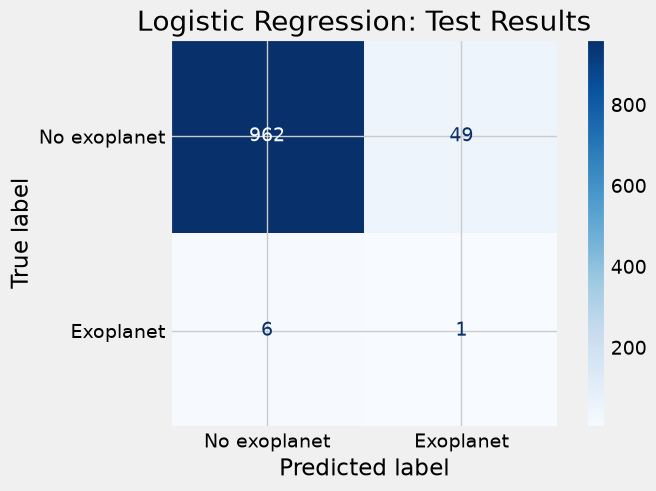

In [156]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(
    y_test,
    predictions,
    labels=[0, 1],
    target_names=['No exoplanet', 'Exoplanet'],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=[0, 1],
    display_labels=['No exoplanet', 'Exoplanet'],
    cmap='Blues'
)
plt.title("Logistic Regression: Test Results")
plt.show()

In [157]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions, labels=[0, 1]))

[[962  49]
 [  6   1]]


### Initial model results

I added a logistic regression pipeline with feature scaling and
balanced class weights, using a stratified 80/20 train-test split.

The model detected 1 of 7 positive test examples, missed 6,
and produced 49 false positives.

- Precision for the positive class: 2%
- Recall for the positive class: 14.3%
- Overall accuracy: 94.6%

This experiment shows why accuracy alone can be misleading
for a highly imbalanced dataset.